### Import Libraries and Data Exploration

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE


from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [103]:
car_insurance_fraud_df = pd.read_csv(r'car_insurance_fraud_dataset.csv')
car_insurance_fraud_df_copy = car_insurance_fraud_df.copy(deep=True)
car_insurance_fraud_df_copy.shape

(30000, 24)

In [104]:
pd.set_option('display.max_columns', 24)
car_insurance_fraud_df_copy.head()

,policy_id,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported
0,POL100000,GA,400,1430.78,74,OTHER,High School,Manager,reading,2024-06-13,Parked Car,Front,Total Loss,NaN,MI,Charlesville,6,1,4,0,Yes,8161.36,11677.60,Y
1,POL100001,PA,300,854.49,74,MALE,College,Lawyer,chess,2025-03-23,Vehicle Theft,Rear,Total Loss,NaN,OH,Joshuaberg,0,3,4,5,No,18561.79,18027.81,N
2,POL100002,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,2025-01-26,Parked Car,Unknown,Total Loss,Police,MI,Reynoldsfurt,14,4,4,1,No,10734.61,10375.59,N
3,POL100003,CA,600,622.42,37,MALE,PhD,Teacher,yachting,2024-06-03,Parked Car,Rear,Total Loss,Police,NC,Josephchester,22,3,3,5,No,13188.92,14204.34,N
4,POL100004,MI,700,1458.17,31,OTHER,PhD,Sales,reading,2024-05-21,Single Vehicle Collision,Side,Minor Damage,Fire,NY,Caitlinfort,18,4,2,4,No,21864.69,24038.84,N


In [105]:
car_insurance_fraud_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   policy_id                    30000 non-null  object 
 1   policy_state                 30000 non-null  object 
 2   policy_deductible            30000 non-null  int64  
 3   policy_annual_premium        30000 non-null  float64
 4   insured_age                  30000 non-null  int64  
 5   insured_sex                  30000 non-null  object 
 6   insured_education_level      30000 non-null  object 
 7   insured_occupation           30000 non-null  object 
 8   insured_hobbies              30000 non-null  object 
 9   incident_date                30000 non-null  object 
 10  incident_type                30000 non-null  object 
 11  collision_type               30000 non-null  object 
 12  incident_severity            30000 non-null  object 
 13  authorities_cont

In [106]:
car_insurance_fraud_df.describe().T

,count,mean,std,min,25%,50%,75%,max
policy_deductible,30000.0,562.783333,250.413012,200.00,300.0000,600.000,800.0000,1000.00
policy_annual_premium,30000.0,1051.255214,260.357163,600.02,826.3200,1051.155,1277.9025,1499.98
insured_age,30000.0,46.500133,16.707778,18.00,32.0000,46.000,61.0000,75.00
incident_hour_of_the_day,30000.0,11.505000,6.896155,0.00,6.0000,12.000,17.0000,23.00
number_of_vehicles_involved,30000.0,2.508933,1.116555,1.00,2.0000,3.000,4.0000,4.00
bodily_injuries,30000.0,1.997600,1.411829,0.00,1.0000,2.000,3.0000,4.00
witnesses,30000.0,2.504667,1.707691,0.00,1.0000,2.000,4.0000,5.00
claim_amount,30000.0,10823.078981,6629.690781,266.74,5350.9475,10204.170,15381.8675,29719.87
total_claim_amount,30000.0,12757.736600,7028.920069,502.18,6685.5075,12740.430,18809.9100,24999.72


In [107]:
car_insurance_fraud_df_copy.drop(columns=['policy_id','incident_city'], inplace=True)
car_insurance_fraud_df_copy.head()

,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported
0,GA,400,1430.78,74,OTHER,High School,Manager,reading,2024-06-13,Parked Car,Front,Total Loss,NaN,MI,6,1,4,0,Yes,8161.36,11677.60,Y
1,PA,300,854.49,74,MALE,College,Lawyer,chess,2025-03-23,Vehicle Theft,Rear,Total Loss,NaN,OH,0,3,4,5,No,18561.79,18027.81,N
2,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,2025-01-26,Parked Car,Unknown,Total Loss,Police,MI,14,4,4,1,No,10734.61,10375.59,N
3,CA,600,622.42,37,MALE,PhD,Teacher,yachting,2024-06-03,Parked Car,Rear,Total Loss,Police,NC,22,3,3,5,No,13188.92,14204.34,N
4,MI,700,1458.17,31,OTHER,PhD,Sales,reading,2024-05-21,Single Vehicle Collision,Side,Minor Damage,Fire,NY,18,4,2,4,No,21864.69,24038.84,N


In [108]:
categorical_columns = car_insurance_fraud_df_copy.select_dtypes(include='object')
numerical_columns = car_insurance_fraud_df_copy.select_dtypes(include='number')

In [109]:
categorical_columns.head()

,policy_state,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,police_report_available,fraud_reported
0,GA,OTHER,High School,Manager,reading,2024-06-13,Parked Car,Front,Total Loss,NaN,MI,Yes,Y
1,PA,MALE,College,Lawyer,chess,2025-03-23,Vehicle Theft,Rear,Total Loss,NaN,OH,No,N
2,MI,OTHER,PhD,Doctor,reading,2025-01-26,Parked Car,Unknown,Total Loss,Police,MI,No,N
3,CA,MALE,PhD,Teacher,yachting,2024-06-03,Parked Car,Rear,Total Loss,Police,NC,No,N
4,MI,OTHER,PhD,Sales,reading,2024-05-21,Single Vehicle Collision,Side,Minor Damage,Fire,NY,No,N


In [110]:
numerical_columns.head()

,policy_deductible,policy_annual_premium,insured_age,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,claim_amount,total_claim_amount
0,400,1430.78,74,6,1,4,0,8161.36,11677.60
1,300,854.49,74,0,3,4,5,18561.79,18027.81
2,400,1247.28,28,14,4,4,1,10734.61,10375.59
3,600,622.42,37,22,3,3,5,13188.92,14204.34
4,700,1458.17,31,18,4,2,4,21864.69,24038.84


In [111]:
for col in categorical_columns:
    print(car_insurance_fraud_df[col].value_counts())
    print('_'*40)

policy_state
GA    3133
NY    3034
OH    3026
MI    3004
PA    2997
NC    2990
FL    2981
IL    2973
CA    2951
TX    2911
Name: count, dtype: int64
________________________________________
insured_sex
OTHER     10088
MALE      10037
FEMALE     9875
Name: count, dtype: int64
________________________________________
insured_education_level
High School    7554
PhD            7514
Masters        7477
College        7455
Name: count, dtype: int64
________________________________________
insured_occupation
Teacher       3799
Doctor        3778
Manager       3777
Clerk         3773
Technician    3758
Lawyer        3725
Sales         3702
Engineer      3688
Name: count, dtype: int64
________________________________________
insured_hobbies
paintball    4345
hiking       4328
yachting     4296
camping      4284
reading      4265
movies       4258
chess        4224
Name: count, dtype: int64
________________________________________
incident_date
2024-07-31    64
2025-06-23    62
2024-05-08    59


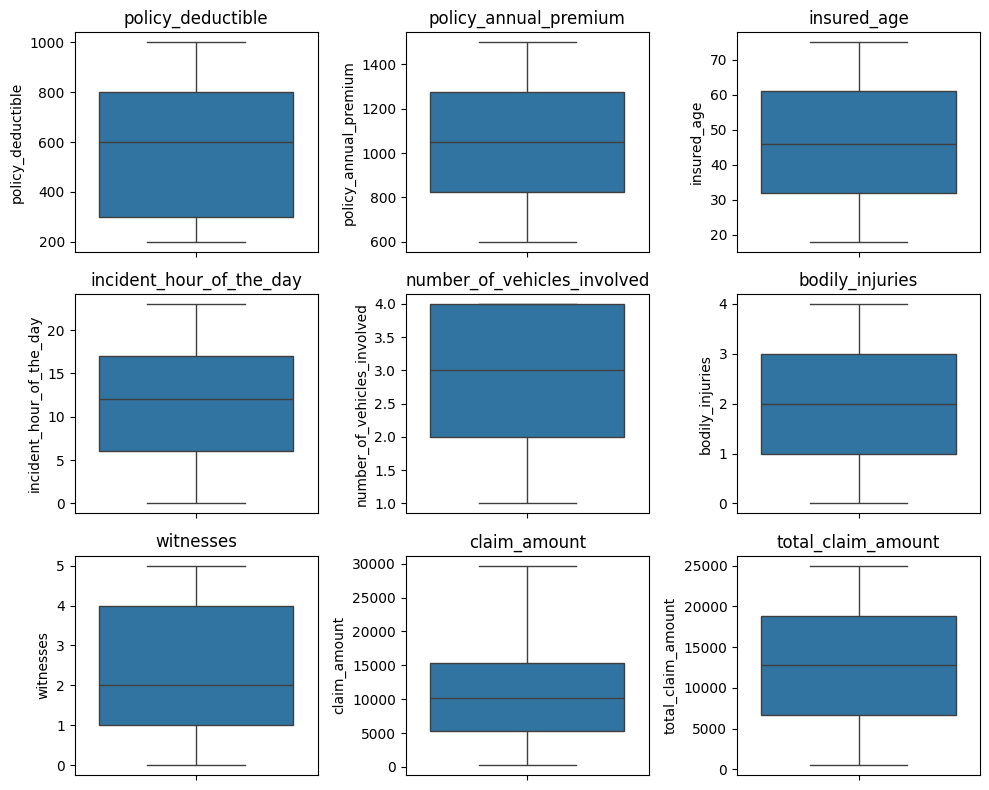

In [112]:
columns = numerical_columns

# Create subplot grid (2x2 here)
fig, axes = plt.subplots(3, 3, figsize=(10, 8))

axes = axes.flatten()  # make it 1D for easy looping

# Loop through columns
for i, col in enumerate(columns):
    sns.boxplot(y=car_insurance_fraud_df_copy[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

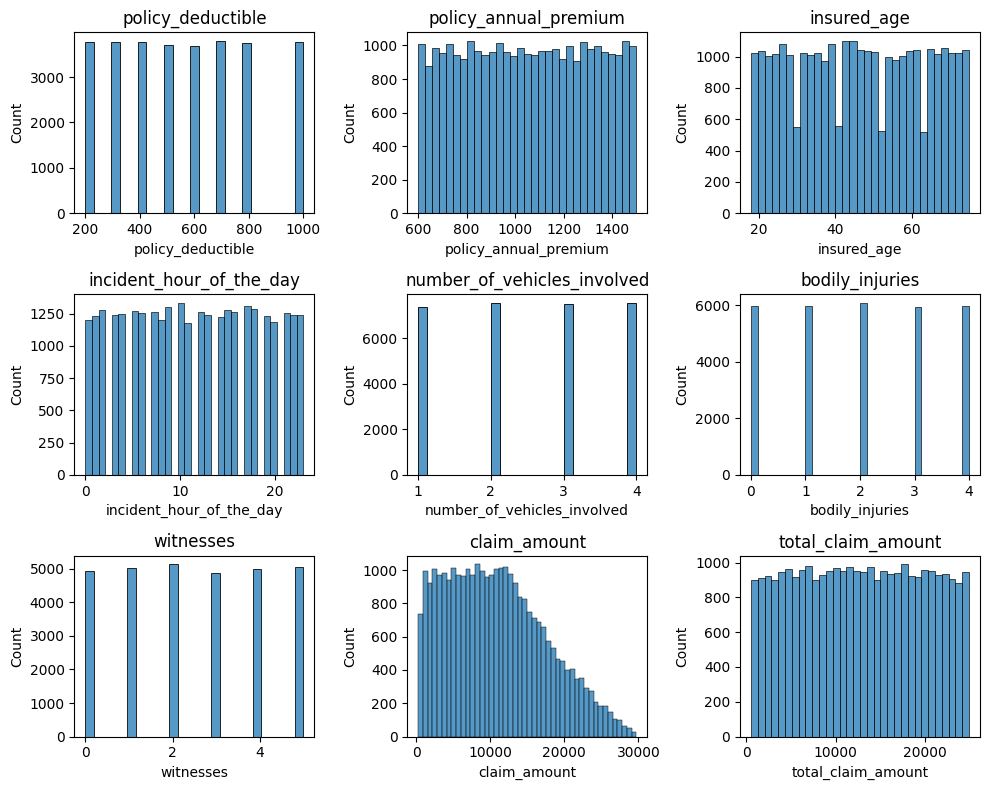

In [113]:
columns = numerical_columns

fig, axes = plt.subplots(3, 3, figsize=(10, 8))

axes = axes.flatten()  

# Loop through columns
for i, col in enumerate(numerical_columns):
    sns.histplot(data=car_insurance_fraud_df_copy, x=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

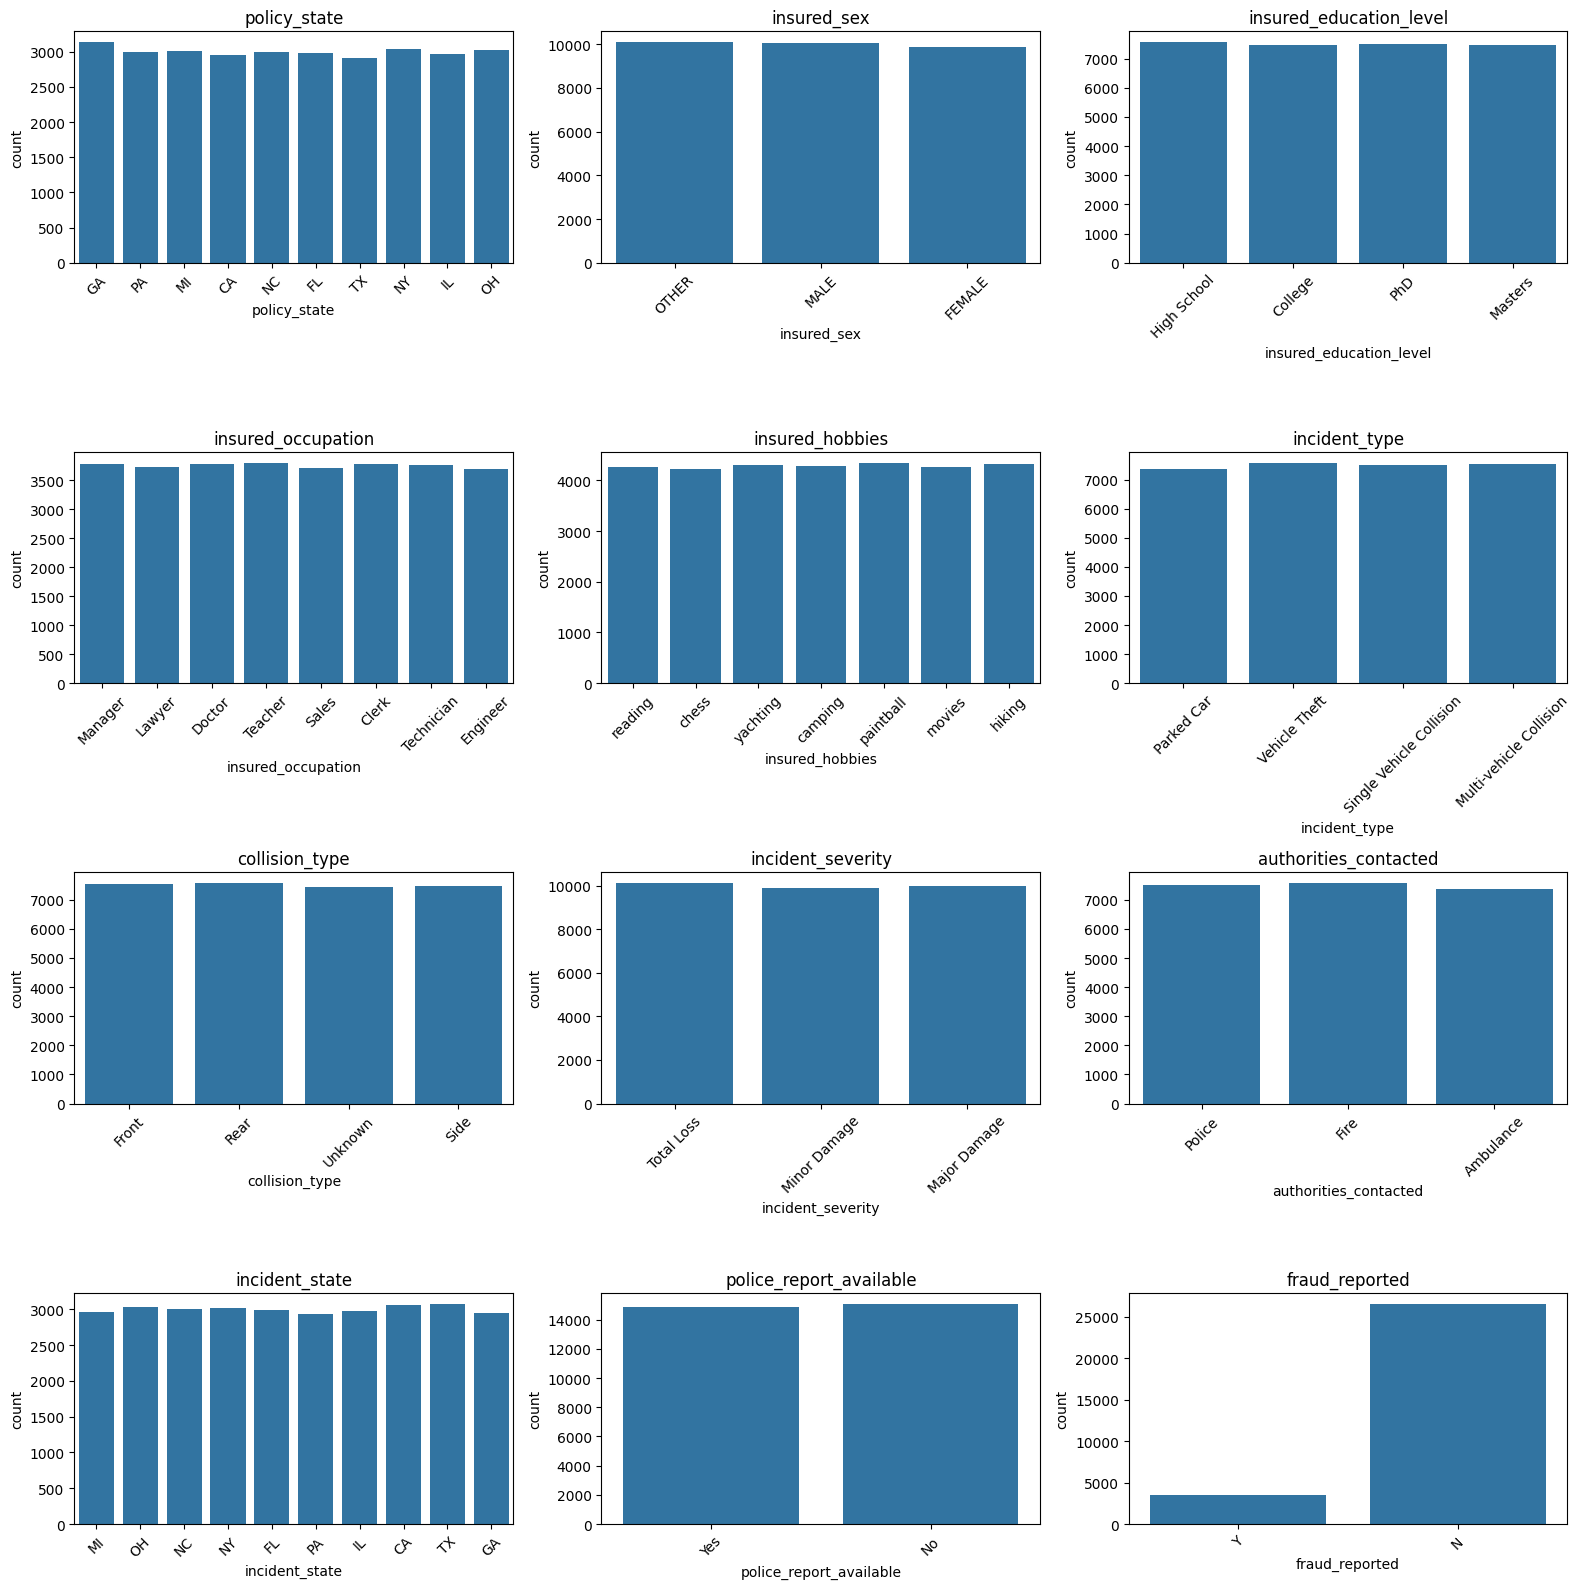

In [114]:
columns = categorical_columns

fig, axes = plt.subplots(4, 3, figsize=(16, 16))

axes = axes.flatten()  

for i, col in enumerate(categorical_columns.drop(['incident_date'], axis=1)):
    sns.countplot(data=car_insurance_fraud_df_copy, x=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)  # optional (for readability)

plt.tight_layout()
plt.show()

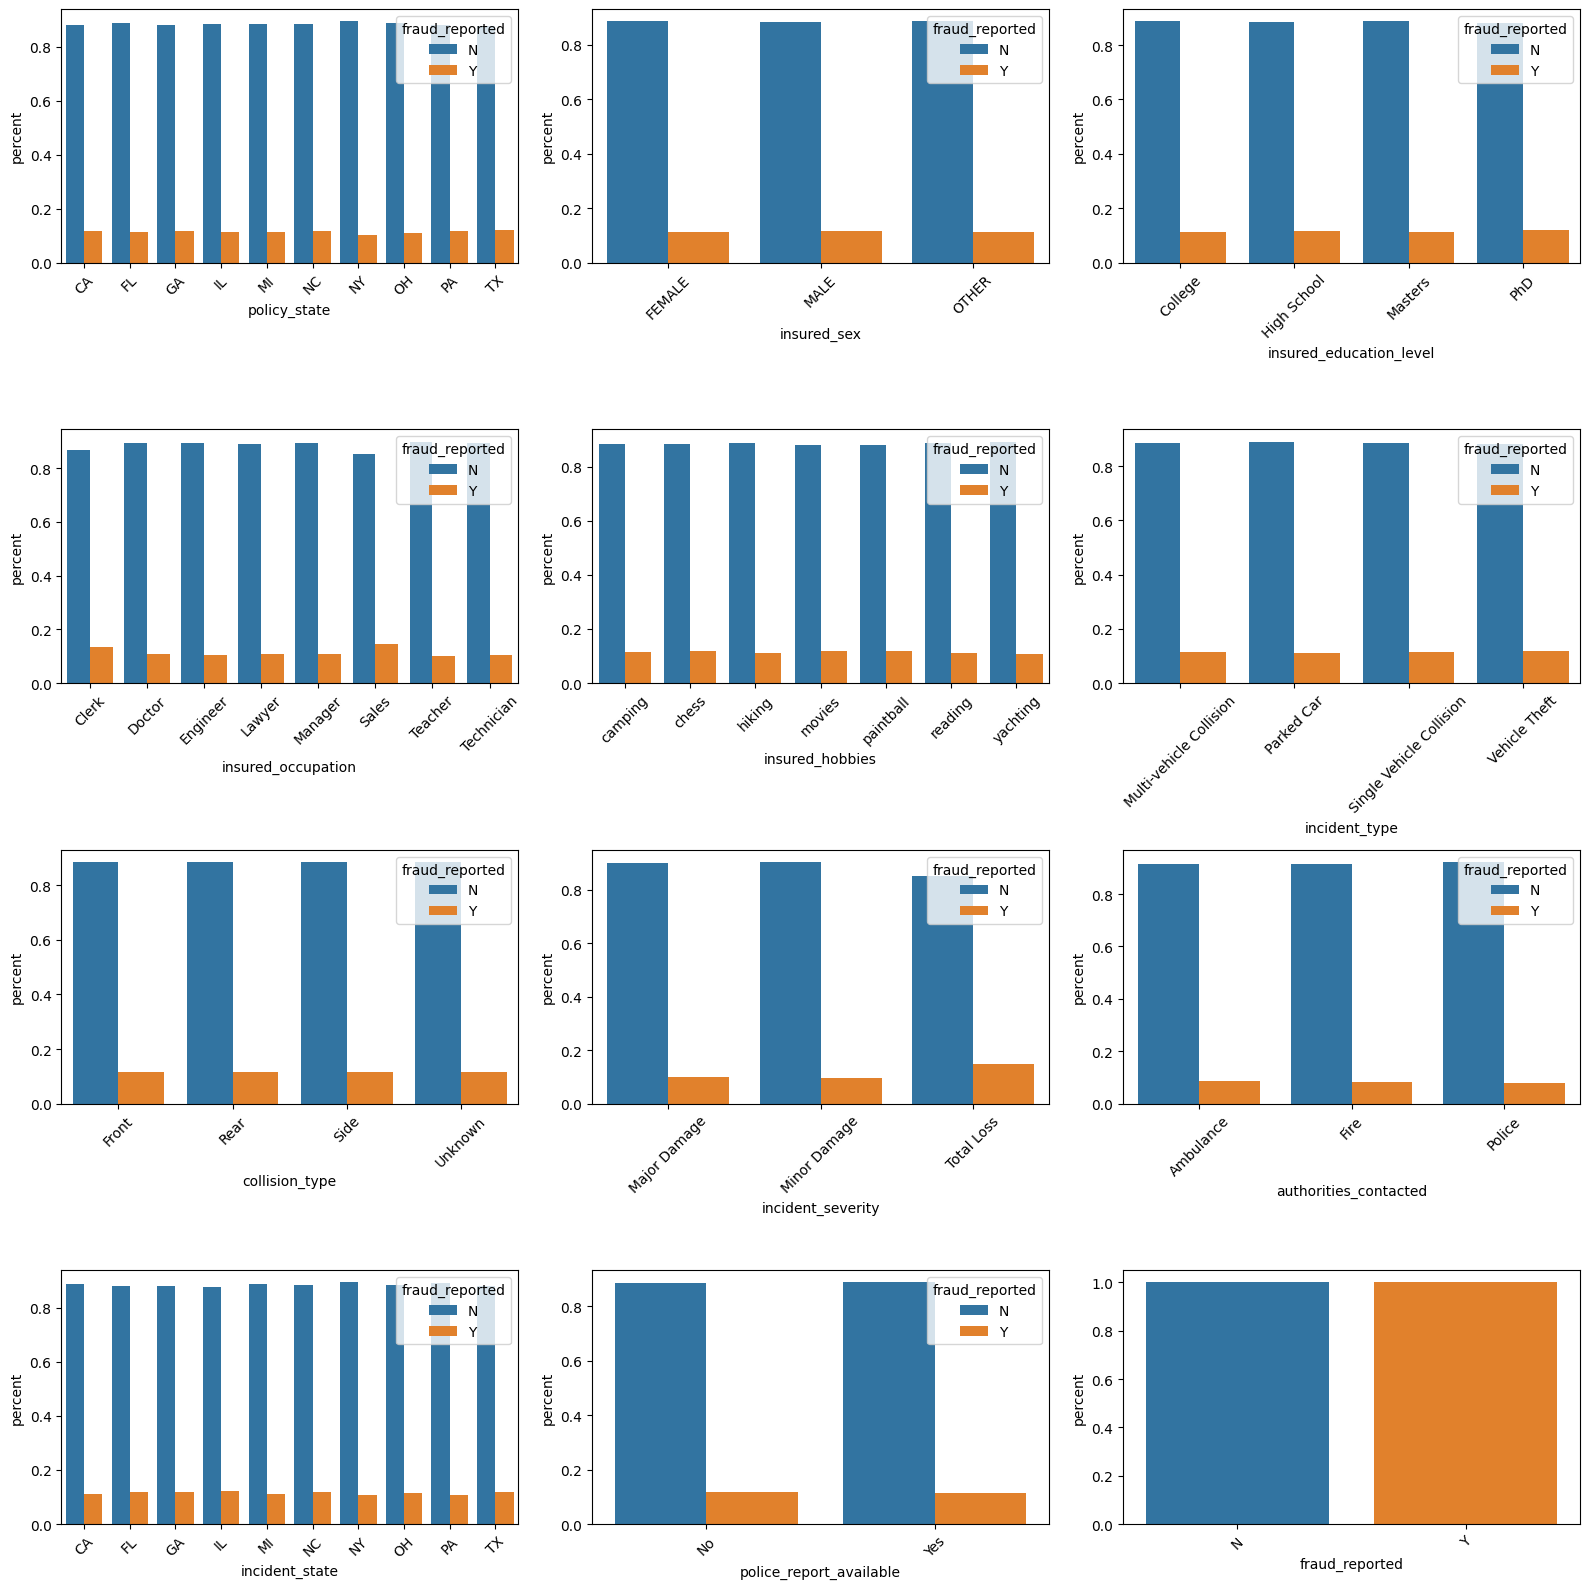

In [115]:
columns = categorical_columns

fig, axes = plt.subplots(4, 3, figsize=(16, 16))

axes = axes.flatten()  

for i, col in enumerate(categorical_columns.drop(['incident_date'], axis=1)):
    temp = (
    car_insurance_fraud_df_copy
    .groupby(col)['fraud_reported']
    .value_counts(normalize=True)
    .rename('percent')
    .reset_index()
    )

    sns.barplot(
        data=temp,
        x=col,
        y='percent',
        hue='fraud_reported',
        ax=axes[i]
    )
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [116]:
columns = ['incident_state', 'incident_severity', 'insured_occupation']
for col in columns:
   print( pd.crosstab(
        car_insurance_fraud_df_copy[col],
        car_insurance_fraud_df_copy['fraud_reported'],
        normalize='index'
    ))
   print('_'*30)


fraud_reported         N         Y
incident_state                    
CA              0.889470  0.110530
FL              0.882432  0.117568
GA              0.880855  0.119145
IL              0.877729  0.122271
MI              0.888289  0.111711
NC              0.882901  0.117099
NY              0.893829  0.106171
OH              0.884997  0.115003
PA              0.890779  0.109221
TX              0.882028  0.117972
______________________________
fraud_reported            N         Y
incident_severity                    
Major Damage       0.900830  0.099170
Minor Damage       0.903833  0.096167
Total Loss         0.851899  0.148101
______________________________
fraud_reported             N         Y
insured_occupation                    
Clerk               0.865889  0.134111
Doctor              0.892800  0.107200
Engineer            0.894252  0.105748
Lawyer              0.889933  0.110067
Manager             0.891978  0.108022
Sales               0.853323  0.146677
Teacher         

#### Data Preprocessing

##### Feature engineering

In [117]:
((car_insurance_fraud_df_copy['total_claim_amount'] - car_insurance_fraud_df_copy['claim_amount']) > 0).value_counts()

True     21546
False     8454
Name: count, dtype: int64

In [118]:
car_insurance_fraud_df_copy['is_overclaimed'] = np.where(
    car_insurance_fraud_df_copy['total_claim_amount'] < car_insurance_fraud_df_copy['claim_amount'],
    'yes',
    'no'
)
car_insurance_fraud_df_copy

,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported,is_overclaimed
0,GA,400,1430.78,74,OTHER,High School,Manager,reading,2024-06-13,Parked Car,Front,Total Loss,NaN,MI,6,1,4,0,Yes,8161.36,11677.60,Y,no
1,PA,300,854.49,74,MALE,College,Lawyer,chess,2025-03-23,Vehicle Theft,Rear,Total Loss,NaN,OH,0,3,4,5,No,18561.79,18027.81,N,yes
2,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,2025-01-26,Parked Car,Unknown,Total Loss,Police,MI,14,4,4,1,No,10734.61,10375.59,N,yes
3,CA,600,622.42,37,MALE,PhD,Teacher,yachting,2024-06-03,Parked Car,Rear,Total Loss,Police,NC,22,3,3,5,No,13188.92,14204.34,N,no
4,MI,700,1458.17,31,OTHER,PhD,Sales,reading,2024-05-21,Single Vehicle Collision,Side,Minor Damage,Fire,NY,18,4,2,4,No,21864.69,24038.84,N,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,NY,200,973.40,47,FEMALE,Masters,Lawyer,paintball,2025-04-04,Vehicle Theft,Unknown,Major Damage,Police,IL,5,3,1,1,No,10502.67,16070.08,N,no
29996,CA,300,869.67,38,MALE,Masters,Sales,hiking,2025-05-22,Parked Car,Unknown,Major Damage,Ambulance,FL,8,3,3,2,No,18892.03,17314.60,N,yes
29997,FL,600,1169.47,57,OTHER,College,Doctor,reading,2025-09-09,Multi-vehicle Collision,Unknown,Total Loss,Fire,TX,7,4,3,1,Yes,2777.06,2954.09,N,no
29998,MI,800,989.41,67,MALE,PhD,Doctor,camping,2024-10-14,Parked Car,Front,Minor Damage,Fire,TX,5,2,2,1,No,4845.58,5945.18,N,no


In [119]:
car_insurance_fraud_df_copy['incident_date'] = pd.to_datetime(car_insurance_fraud_df_copy['incident_date'])
car_insurance_fraud_df_copy['incident_date']

0       2024-06-13
1       2025-03-23
2       2025-01-26
3       2024-06-03
4       2024-05-21
           ...    
29995   2025-04-04
29996   2025-05-22
29997   2025-09-09
29998   2024-10-14
29999   2024-04-29
Name: incident_date, Length: 30000, dtype: datetime64[ns]

In [120]:
car_insurance_fraud_df_copy['incident_year'] = car_insurance_fraud_df_copy['incident_date'].dt.year
car_insurance_fraud_df_copy['incident_month'] = car_insurance_fraud_df_copy['incident_date'].dt.month
car_insurance_fraud_df_copy['incident_month_day'] = car_insurance_fraud_df_copy['incident_date'].dt.day
car_insurance_fraud_df_copy['incident_week_day'] = car_insurance_fraud_df_copy['incident_date'].dt.dayofweek
car_insurance_fraud_df_copy['day_name'] = car_insurance_fraud_df_copy['incident_date'].dt.day_name()
car_insurance_fraud_df_copy['month_name'] = car_insurance_fraud_df_copy['incident_date'].dt.month_name()
car_insurance_fraud_df_copy['is_weekend'] = np.where(car_insurance_fraud_df_copy['incident_week_day'].isin([5, 6]), 1, 0)
car_insurance_fraud_df_copy['quarter'] = car_insurance_fraud_df_copy['incident_date'].dt.quarter

car_insurance_fraud_df_copy.head()

,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,incident_type,collision_type,incident_severity,...,claim_amount,total_claim_amount,fraud_reported,is_overclaimed,incident_year,incident_month,incident_month_day,incident_week_day,day_name,month_name,is_weekend,quarter
0,GA,400,1430.78,74,OTHER,High School,Manager,reading,2024-06-13,Parked Car,Front,Total Loss,...,8161.36,11677.60,Y,no,2024,6,13,3,Thursday,June,0,2
1,PA,300,854.49,74,MALE,College,Lawyer,chess,2025-03-23,Vehicle Theft,Rear,Total Loss,...,18561.79,18027.81,N,yes,2025,3,23,6,Sunday,March,1,1
2,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,2025-01-26,Parked Car,Unknown,Total Loss,...,10734.61,10375.59,N,yes,2025,1,26,6,Sunday,January,1,1
3,CA,600,622.42,37,MALE,PhD,Teacher,yachting,2024-06-03,Parked Car,Rear,Total Loss,...,13188.92,14204.34,N,no,2024,6,3,0,Monday,June,0,2
4,MI,700,1458.17,31,OTHER,PhD,Sales,reading,2024-05-21,Single Vehicle Collision,Side,Minor Damage,...,21864.69,24038.84,N,no,2024,5,21,1,Tuesday,May,0,2


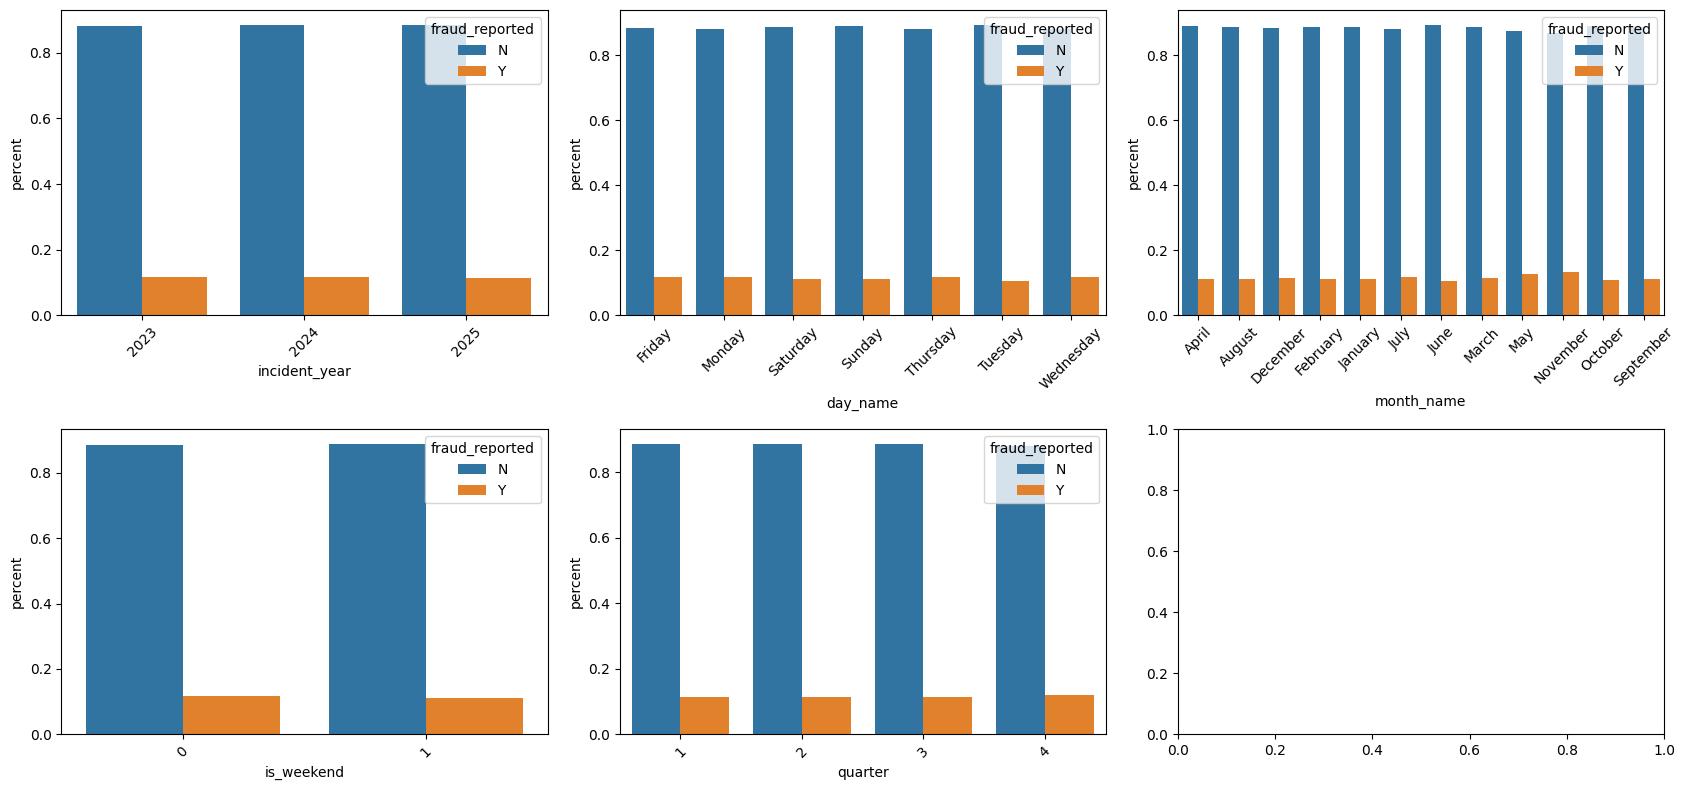

In [121]:
columns = ['incident_year','day_name', 'month_name', 'is_weekend', 'quarter']

fig, axes = plt.subplots(2, 3, figsize=(17, 8))

axes = axes.flatten()  

for i, col in enumerate(columns):
    temp = (
    car_insurance_fraud_df_copy
    .groupby(col)['fraud_reported']
    .value_counts(normalize=True)
    .rename('percent')
    .reset_index()
    )

    sns.barplot(
        data=temp,
        x=col,
        y='percent',
        hue='fraud_reported',
        ax=axes[i]
    )
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [122]:
for col in columns:
   print( pd.crosstab(
        car_insurance_fraud_df_copy[col],
        car_insurance_fraud_df_copy['fraud_reported'],
        normalize='index'
    ))
   print('_'*30)

fraud_reported         N         Y
incident_year                     
2023            0.882827  0.117173
2024            0.884626  0.115374
2025            0.886564  0.113436
______________________________
fraud_reported         N         Y
day_name                          
Friday          0.882380  0.117620
Monday          0.881135  0.118865
Saturday        0.888145  0.111855
Sunday          0.888709  0.111291
Thursday        0.881296  0.118704
Tuesday         0.894468  0.105532
Wednesday       0.881251  0.118749
______________________________
fraud_reported         N         Y
month_name                        
April           0.890083  0.109917
August          0.889060  0.110940
December        0.884930  0.115070
February        0.887569  0.112431
January         0.887532  0.112468
July            0.882538  0.117462
June            0.895155  0.104845
March           0.886328  0.113672
May             0.874507  0.125493
November        0.867879  0.132121
October         0.890534  0.

##### Data Cleaning

In [123]:
columns = ['incident_year', 'incident_month', 'day_name', 'incident_month_day','month_name', 'is_weekend', 'quarter','incident_week_day','incident_date']
car_insurance_fraud_df_copy.drop(columns, inplace=True, axis=1)

In [124]:
car_insurance_fraud_df_copy.head()

,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported,is_overclaimed
0,GA,400,1430.78,74,OTHER,High School,Manager,reading,Parked Car,Front,Total Loss,NaN,MI,6,1,4,0,Yes,8161.36,11677.60,Y,no
1,PA,300,854.49,74,MALE,College,Lawyer,chess,Vehicle Theft,Rear,Total Loss,NaN,OH,0,3,4,5,No,18561.79,18027.81,N,yes
2,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,Parked Car,Unknown,Total Loss,Police,MI,14,4,4,1,No,10734.61,10375.59,N,yes
3,CA,600,622.42,37,MALE,PhD,Teacher,yachting,Parked Car,Rear,Total Loss,Police,NC,22,3,3,5,No,13188.92,14204.34,N,no
4,MI,700,1458.17,31,OTHER,PhD,Sales,reading,Single Vehicle Collision,Side,Minor Damage,Fire,NY,18,4,2,4,No,21864.69,24038.84,N,no


In [125]:
car_insurance_fraud_df_copy['collision_type'].value_counts()

collision_type
Rear       7566
Front      7540
Side       7461
Unknown    7433
Name: count, dtype: int64

In [126]:
X = car_insurance_fraud_df_copy.drop('fraud_reported', axis=1)
Y = car_insurance_fraud_df_copy['fraud_reported']

x_train, x_test, y_train, y_test = train_test_split(X, Y,                           
                                                    random_state=0,
                                                    test_size=0.3,
                                                    stratify=Y)

In [127]:
x_train['authorities_contacted'].value_counts(dropna=False, normalize=True)

authorities_contacted
NaN          0.253381
Fire         0.252190
Police       0.248810
Ambulance    0.245619
Name: proportion, dtype: float64

In [128]:
imputer = SimpleImputer(strategy='constant', fill_value='Not Contacted')
x_train[['authorities_contacted']] = imputer.fit_transform(x_train[['authorities_contacted']])
x_test[['authorities_contacted']] = imputer.transform(x_test[['authorities_contacted']])
x_train['authorities_contacted'].value_counts()

authorities_contacted
Not Contacted    5321
Fire             5296
Police           5225
Ambulance        5158
Name: count, dtype: int64

In [129]:
cols = x_train.select_dtypes(include='object')
cols = cols.columns.to_list()
cols

['policy_state',
 'insured_sex',
 'insured_education_level',
 'insured_occupation',
 'insured_hobbies',
 'incident_type',
 'collision_type',
 'incident_severity',
 'authorities_contacted',
 'incident_state',
 'police_report_available',
 'is_overclaimed']

In [130]:
for col in cols:
    print(x_train[col].value_counts())
    print('_'*40)

policy_state
GA    2204
OH    2141
FL    2140
NY    2123
MI    2122
IL    2077
NC    2072
PA    2064
CA    2039
TX    2018
Name: count, dtype: int64
________________________________________
insured_sex
OTHER     7077
MALE      6984
FEMALE    6939
Name: count, dtype: int64
________________________________________
insured_education_level
High School    5288
PhD            5287
College        5235
Masters        5190
Name: count, dtype: int64
________________________________________
insured_occupation
Teacher       2697
Doctor        2665
Manager       2626
Clerk         2623
Technician    2622
Sales         2615
Lawyer        2588
Engineer      2564
Name: count, dtype: int64
________________________________________
insured_hobbies
paintball    3042
yachting     3027
camping      3021
reading      3010
hiking       2998
movies       2979
chess        2923
Name: count, dtype: int64
________________________________________
incident_type
Vehicle Theft               5366
Single Vehicle Collis

In [131]:
frequency_cols = ['policy_state', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'incident_type', 'collision_type',
        'incident_severity', 'authorities_contacted', 'incident_state']

for col in frequency_cols:
    freq_map = x_train[col].value_counts(normalize=True)
    x_train[col] = x_train[col].map(freq_map)
    x_test[col] = x_test[col].map(freq_map)

x_train

,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,is_overclaimed
3892,0.097095,200,1369.46,42,0.332571,0.249286,0.125048,0.143333,0.255524,0.249667,0.332286,0.253381,0.100429,0,4,0,5,Yes,1630.39,2509.36,no
13185,0.101048,200,745.93,33,0.332571,0.251762,0.128429,0.142762,0.250619,0.249238,0.331143,0.253381,0.099000,12,1,2,5,Yes,19011.31,16010.12,yes
20661,0.098286,600,1459.34,64,0.330429,0.249286,0.124857,0.142762,0.243714,0.252619,0.331143,0.252190,0.100048,22,3,4,5,No,16919.25,15708.03,yes
19997,0.098905,400,910.63,75,0.337000,0.251762,0.124857,0.143333,0.243714,0.252619,0.332286,0.248810,0.099000,23,4,2,0,No,12899.43,13789.69,no
15996,0.097095,1000,1092.29,40,0.332571,0.251810,0.123238,0.144143,0.250143,0.249238,0.331143,0.245619,0.100048,15,3,1,0,Yes,21893.55,18339.07,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13718,0.098905,200,676.26,69,0.332571,0.247143,0.128429,0.144143,0.250619,0.249667,0.331143,0.245619,0.100048,3,1,1,2,No,10363.02,10817.21,no
9160,0.101952,400,1302.39,48,0.337000,0.251762,0.128429,0.144857,0.255524,0.248476,0.332286,0.248810,0.098286,13,2,2,0,No,6703.53,10450.95,no
11868,0.097095,1000,1180.76,63,0.330429,0.251810,0.123238,0.143857,0.243714,0.249238,0.331143,0.253381,0.100429,22,3,4,3,No,20427.70,18007.69,yes
17542,0.101095,300,937.79,45,0.332571,0.247143,0.123238,0.143333,0.243714,0.252619,0.336571,0.253381,0.100048,13,2,1,5,No,919.38,1098.88,no


In [132]:
OneHot_encoder_cols = ['police_report_available', 'is_overclaimed']
encoder = OneHotEncoder(sparse_output=False, drop='first').set_output(transform='pandas')
encoder.fit(x_train[OneHot_encoder_cols])

,categories,'auto'
,drop,'first'
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [133]:
OneHot_encoder_cols = ['police_report_available', 'is_overclaimed']
x_train[OneHot_encoder_cols] = encoder.transform(x_train[OneHot_encoder_cols])
x_test[OneHot_encoder_cols] = encoder.transform(x_test[OneHot_encoder_cols])

x_train

,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,is_overclaimed
3892,0.097095,200,1369.46,42,0.332571,0.249286,0.125048,0.143333,0.255524,0.249667,0.332286,0.253381,0.100429,0,4,0,5,1.0,1630.39,2509.36,0.0
13185,0.101048,200,745.93,33,0.332571,0.251762,0.128429,0.142762,0.250619,0.249238,0.331143,0.253381,0.099000,12,1,2,5,1.0,19011.31,16010.12,1.0
20661,0.098286,600,1459.34,64,0.330429,0.249286,0.124857,0.142762,0.243714,0.252619,0.331143,0.252190,0.100048,22,3,4,5,0.0,16919.25,15708.03,1.0
19997,0.098905,400,910.63,75,0.337000,0.251762,0.124857,0.143333,0.243714,0.252619,0.332286,0.248810,0.099000,23,4,2,0,0.0,12899.43,13789.69,0.0
15996,0.097095,1000,1092.29,40,0.332571,0.251810,0.123238,0.144143,0.250143,0.249238,0.331143,0.245619,0.100048,15,3,1,0,1.0,21893.55,18339.07,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13718,0.098905,200,676.26,69,0.332571,0.247143,0.128429,0.144143,0.250619,0.249667,0.331143,0.245619,0.100048,3,1,1,2,0.0,10363.02,10817.21,0.0
9160,0.101952,400,1302.39,48,0.337000,0.251762,0.128429,0.144857,0.255524,0.248476,0.332286,0.248810,0.098286,13,2,2,0,0.0,6703.53,10450.95,0.0
11868,0.097095,1000,1180.76,63,0.330429,0.251810,0.123238,0.143857,0.243714,0.249238,0.331143,0.253381,0.100429,22,3,4,3,0.0,20427.70,18007.69,1.0
17542,0.101095,300,937.79,45,0.332571,0.247143,0.123238,0.143333,0.243714,0.252619,0.336571,0.253381,0.100048,13,2,1,5,0.0,919.38,1098.88,0.0


In [134]:
y_encoding = LabelEncoder()

y_encoding.fit(y_train)
y_train = y_encoding.transform(y_train)
y_test = y_encoding.transform(y_test)

y_train

array([0, 0, 0, ..., 1, 0, 0], shape=(21000,))

In [140]:
numerical_columns.columns

Index(['policy_deductible', 'policy_annual_premium', 'insured_age',
       'incident_hour_of_the_day', 'number_of_vehicles_involved',
       'bodily_injuries', 'witnesses', 'claim_amount', 'total_claim_amount'],
      dtype='object')

In [141]:
scaler = MinMaxScaler()
scaler.fit(x_train[numerical_columns.columns])

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [ ]:
x_train = pd.DataFrame(scaler.transform(x_train), columns=x_train.columns)
x_test = pd.DataFrame(scaler.transform(x_test), columns=x_test.columns)

x_train

,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,is_overclaimed
0,0.112903,0.000,0.854971,0.421053,0.326087,0.459184,0.466165,0.731092,1.000000,0.287356,0.210526,1.000000,0.454545,0.000000,1.000000,0.00,1.0,1.0,0.046299,0.081939,0.0
1,0.559140,0.000,0.162129,0.263158,0.326087,0.989796,1.000000,0.630252,0.584677,0.183908,0.000000,1.000000,0.151515,0.521739,0.000000,0.50,1.0,1.0,0.636420,0.633080,1.0
2,0.247312,0.500,0.954842,0.807018,0.000000,0.459184,0.436090,0.630252,0.000000,1.000000,0.000000,0.846626,0.373737,0.956522,0.666667,1.00,1.0,0.0,0.565390,0.620748,1.0
3,0.317204,0.250,0.345138,1.000000,1.000000,0.989796,0.436090,0.731092,0.000000,1.000000,0.210526,0.411043,0.151515,1.000000,1.000000,0.50,0.0,0.0,0.428908,0.542435,0.0
4,0.112903,1.000,0.546991,0.385965,0.326087,1.000000,0.180451,0.873950,0.544355,0.183908,0.000000,0.000000,0.373737,0.652174,0.666667,0.25,0.0,1.0,0.734279,0.728155,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20995,0.317204,0.000,0.084715,0.894737,0.326087,0.000000,1.000000,0.873950,0.584677,0.287356,0.000000,0.000000,0.373737,0.130435,0.000000,0.25,0.4,0.0,0.342791,0.421090,0.0
20996,0.661290,0.250,0.780446,0.526316,1.000000,0.989796,1.000000,1.000000,1.000000,0.000000,0.210526,0.411043,0.000000,0.565217,0.333333,0.50,0.0,0.0,0.218543,0.406138,0.0
20997,0.112903,1.000,0.645295,0.789474,0.000000,1.000000,0.180451,0.823529,0.000000,0.183908,0.000000,1.000000,0.454545,0.956522,0.666667,1.00,0.6,0.0,0.684510,0.714627,1.0
20998,0.564516,0.125,0.375317,0.473684,0.326087,0.000000,0.180451,0.731092,0.000000,1.000000,1.000000,1.000000,0.373737,0.565217,0.333333,0.25,1.0,0.0,0.022159,0.024359,0.0


In [137]:
smote = SMOTE(random_state=0)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

In [138]:
x_train_resampled

,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,is_overclaimed
0,0.112903,0.000000,0.854971,0.421053,0.326087,0.459184,0.466165,0.731092,1.000000,0.287356,0.210526,1.000000,0.454545,0.000000,1.000000,0.000000,1.000000,1.0,0.046299,0.081939,0.0
1,0.559140,0.000000,0.162129,0.263158,0.326087,0.989796,1.000000,0.630252,0.584677,0.183908,0.000000,1.000000,0.151515,0.521739,0.000000,0.500000,1.000000,1.0,0.636420,0.633080,1.0
2,0.247312,0.500000,0.954842,0.807018,0.000000,0.459184,0.436090,0.630252,0.000000,1.000000,0.000000,0.846626,0.373737,0.956522,0.666667,1.000000,1.000000,0.0,0.565390,0.620748,1.0
3,0.317204,0.250000,0.345138,1.000000,1.000000,0.989796,0.436090,0.731092,0.000000,1.000000,0.210526,0.411043,0.151515,1.000000,1.000000,0.500000,0.000000,0.0,0.428908,0.542435,0.0
4,0.112903,1.000000,0.546991,0.385965,0.326087,1.000000,0.180451,0.873950,0.544355,0.183908,0.000000,0.000000,0.373737,0.652174,0.666667,0.250000,0.000000,1.0,0.734279,0.728155,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37179,0.558803,0.625000,0.472830,0.348301,0.000000,0.286708,0.400704,0.910089,1.000000,1.000000,1.000000,1.000000,0.373737,0.770446,0.237764,1.000000,0.885317,0.0,0.122645,0.164498,0.0
37180,0.282436,0.603509,0.358163,0.595537,1.000000,0.505674,0.436458,0.000000,0.584677,0.262654,0.000000,0.846626,0.500621,0.631121,0.971346,0.771491,0.451578,1.0,0.208769,0.234088,1.0
37181,0.622511,0.522841,0.849876,0.599873,1.000000,0.041954,0.391015,0.988483,0.544355,0.183908,1.000000,0.000000,0.425013,0.165968,0.636211,0.227159,0.036546,0.0,0.274550,0.305109,1.0
37182,0.313135,0.125000,0.554447,0.155798,1.000000,0.469752,0.384657,0.475777,0.584677,0.003663,0.210526,0.829764,0.372933,0.134764,0.346611,0.500000,0.803983,1.0,0.527328,0.525108,1.0
